# Importando bibliotecas

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Leitura

In [54]:
#Leitura do arquivo
df = pd.read_csv('Global_AI_Content_Impact_Dataset.csv', sep = ',')
#Primeiras 20 linhas
df.head()

,Country,Year,Industry,AI Adoption Rate (%),AI-Generated Content Volume (TBs per year),Job Loss Due to AI (%),Revenue Increase Due to AI (%),Human-AI Collaboration Rate (%),Top AI Tools Used,Regulation Status,Consumer Trust in AI (%),Market Share of AI Companies (%)
0,South Korea,2022,Media,44.29,33.09,16.77,46.12,74.79,Bard,Strict,40.77,18.73
1,China,2025,Legal,34.75,66.74,46.89,52.46,26.17,DALL-E,Strict,35.67,35.02
2,USA,2022,Automotive,81.06,96.13,10.66,45.60,39.66,Stable Diffusion,Moderate,54.47,22.76
3,France,2021,Legal,85.24,93.76,27.70,78.24,29.45,Claude,Moderate,51.84,1.93
4,France,2021,Gaming,78.95,45.62,17.45,1.05,21.70,Midjourney,Strict,41.77,21.41


# Estatísticas descritivas e correlação


## Estatísticas descritivas

Começamos com estatísticas descritivas gerais da base de dados

In [55]:
df.describe()

,Year,AI Adoption Rate (%),AI-Generated Content Volume (TBs per year),Job Loss Due to AI (%),Revenue Increase Due to AI (%),Human-AI Collaboration Rate (%),Consumer Trust in AI (%),Market Share of AI Companies (%)
count,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,2022.315000,54.265850,46.07260,25.788250,39.719450,54.102150,59.425150,26.569550
std,1.825496,24.218067,29.16122,13.901105,23.829545,19.247079,17.319668,14.023729
min,2020.000000,10.530000,1.04000,0.090000,0.140000,20.210000,30.120000,1.180000
25%,2021.000000,33.222500,20.32250,14.995000,17.907500,37.770000,44.755000,14.052500
50%,2022.000000,53.310000,44.32000,25.735000,42.100000,54.515000,59.215000,27.390000
75%,2024.000000,76.220000,71.62000,37.417500,58.697500,69.402500,74.885000,38.432500
max,2025.000000,94.760000,99.06000,49.710000,79.550000,88.290000,89.880000,49.280000


Também parace proveitoso gerar estatísticas descritivas por país

In [56]:
quantitative_cols = ['AI Adoption Rate (%)', 'AI-Generated Content Volume (TBs per year)',
                     'Job Loss Due to AI (%)', 'Revenue Increase Due to AI (%)',
                     'Human-AI Collaboration Rate (%)', 'Consumer Trust in AI (%)',
                     'Market Share of AI Companies (%)']

categorical_cols = ['Country','Year', 'Industry', 'Top AI Tools Used', 'Regulation Status']


estatisticas = ["mean", "std"]
agg_dict = {col: estatisticas for col in quantitative_cols}
agg_dict["Year"] = "median"
df.groupby("Country").agg(agg_dict).round(2)

AI Adoption Rate (%)         \
                            mean    std   
Country                                   
Australia                  56.08  26.16   
Canada                     52.19  23.47   
China                      52.89  25.38   
France                     56.52  23.69   
Germany                    51.46  27.43   
India                      51.81  20.12   
Japan                      54.21  25.47   
South Korea                50.56  24.36   
UK                         64.69  24.83   
USA                        52.08  24.50   

            AI-Generated Content Volume (TBs per year)         \
                                                  mean    std   
Country                                                         
Australia                                        48.77  30.25   
Canada                                           49.11  32.00   
China                                            52.83  29.02   
France                                           47.43  28.73   
Germany                                          44.79  26.83   
India                                            45.00  29.69   
Japan                                            40.25  31.34   
South Korea                                      48.69  29.86   
UK                                               39.09  28.15   
USA                                              46.05  29.69   

            Job Loss Due to AI (%)        Revenue Increase Due to AI (%)  \
                              mean    std                           mean   
Country                                                                    
Australia                    18.82  13.74                          49.70   
Canada                       30.99  13.47                          38.75   
China                        29.09  13.42                          42.60   
France                       26.48  13.86                          39.55   
Germany                      28.10  14.35                          40.58   
India                        25.23  15.94                          40.08   
Japan                        25.51  12.78                          34.61   
South Korea                  25.54  11.31                          34.25   
UK                           27.13  14.21                          36.12   
USA                          20.71  14.41                          43.52   

                   Human-AI Collaboration Rate (%)         \
               std                            mean    std   
Country                                                     
Australia    23.73                           59.48  19.37   
Canada       24.01                           55.20  16.03   
China        27.45                           54.51  17.12   
France       24.09                           52.76  20.83   
Germany      27.16                           49.63  20.21   
India        22.33                           54.20  21.47   
Japan        17.76                           42.38  19.37   
South Korea  24.24                           59.47  20.10   
UK           26.33                           58.27  14.19   
USA          22.81                           57.26  19.05   

            Consumer Trust in AI (%)        Market Share of AI Companies (%)  \
                                mean    std                             mean   
Country                                                                        
Australia                      63.58  13.73                            23.69   
Canada                         62.15  17.55                            28.28   
China                          60.32  17.56                            27.06   
France                         58.44  16.56                            27.19   
Germany                        64.95  16.57                            30.46   
India                          59.92  16.85                            28.34   
Japan                          61.00  20.54                            27.15   
South Korea            

Bem como estatísticas por ano:

In [57]:
estatisticas = ["mean", "std"]
agg_dict = {col: estatisticas for col in quantitative_cols}
df.groupby("Year").agg(agg_dict).round(2)

AI Adoption Rate (%)        AI-Generated Content Volume (TBs per year)  \
                     mean    std                                       mean   
Year                                                                          
2020                50.99  24.33                                      41.83   
2021                57.57  22.95                                      53.78   
2022                52.99  24.18                                      46.82   
2023                59.68  26.04                                      37.69   
2024                51.26  24.35                                      52.60   
2025                54.26  24.17                                      46.67   

            Job Loss Due to AI (%)        Revenue Increase Due to AI (%)  \
        std                   mean    std                           mean   
Year                                                                       
2020  26.78                  28.17  12.87                          44.20   
2021  27.54                  28.23  14.56                          42.99   
2022  30.42                  22.82  13.11                          35.48   
2023  28.05                  24.45  13.43                          33.03   
2024  30.68                  26.28  17.39                          42.45   
2025  31.38                  23.92  13.24                          38.33   

            Human-AI Collaboration Rate (%)        Consumer Trust in AI (%)  \
        std                            mean    std                     mean   
Year                                                                          
2020  20.51                           54.12  19.30                    59.21   
2021  24.82                           53.15  21.67                    59.87   
2022  25.15                           48.78  17.74                    59.44   
2023  24.10                           57.13  14.68                    62.29   
2024  24.96                           52.99  21.70                    58.07   
2025  24.50                           57.59  19.82                    57.94   

            Market Share of AI Companies (%)         
        std                             mean    std  
Year                                                 
2020  17.00                            24.55  14.37  
2021  16.36                            27.33  15.38  
2022  18.90                            26.57  11.60  
2023  18.20                            27.65  13.23  
2024  19.19                            29.70  15.81  
2025  16.14                            25.72  14.10

E por setor:

In [58]:
agg_dict = {col: ["mean"] for col in quantitative_cols}
agg_dict["Year"] = "median"
df.groupby("Industry").agg(agg_dict)

,AI Adoption Rate (%),AI-Generated Content Volume (TBs per year),Job Loss Due to AI (%),Revenue Increase Due to AI (%),Human-AI Collaboration Rate (%),Consumer Trust in AI (%),Market Share of AI Companies (%),Year
,mean,mean,mean,mean,mean,mean,mean,median
Industry,,,,,,,,
Automotive,54.887895,43.159474,28.916842,46.482632,55.906316,61.240000,29.591579,2022.0
Education,57.028235,60.822941,26.142353,39.543529,58.875882,51.650000,22.835882,2021.0
Finance,55.764286,37.545000,27.790000,36.257143,53.609286,56.180714,28.995714,2022.0
Gaming,60.416296,44.470370,27.204074,33.234444,53.096296,61.342963,24.058148,2023.0
Healthcare,55.734118,46.971765,25.579412,38.586471,55.227059,60.160588,29.642941,2023.0
Legal,56.077647,59.902941,28.234118,41.824118,50.743529,57.789412,20.238824,2023.0
Manufacturing,57.014444,49.809444,32.746111,42.807222,55.966667,58.272778,25.964444,2021.0
Marketing,54.244211,37.197368,19.577895,36.813684,55.324211,58.671579,28.681579,2023.0


## Correlações

Ao avaliar as relações entre as variáveis, notamos que de forma agregada parece não haver relação, mas quando dividimos por país/setor obtemos relações que podem ser exploradas

Primeiro plotamos as variáveis numéricas entre si

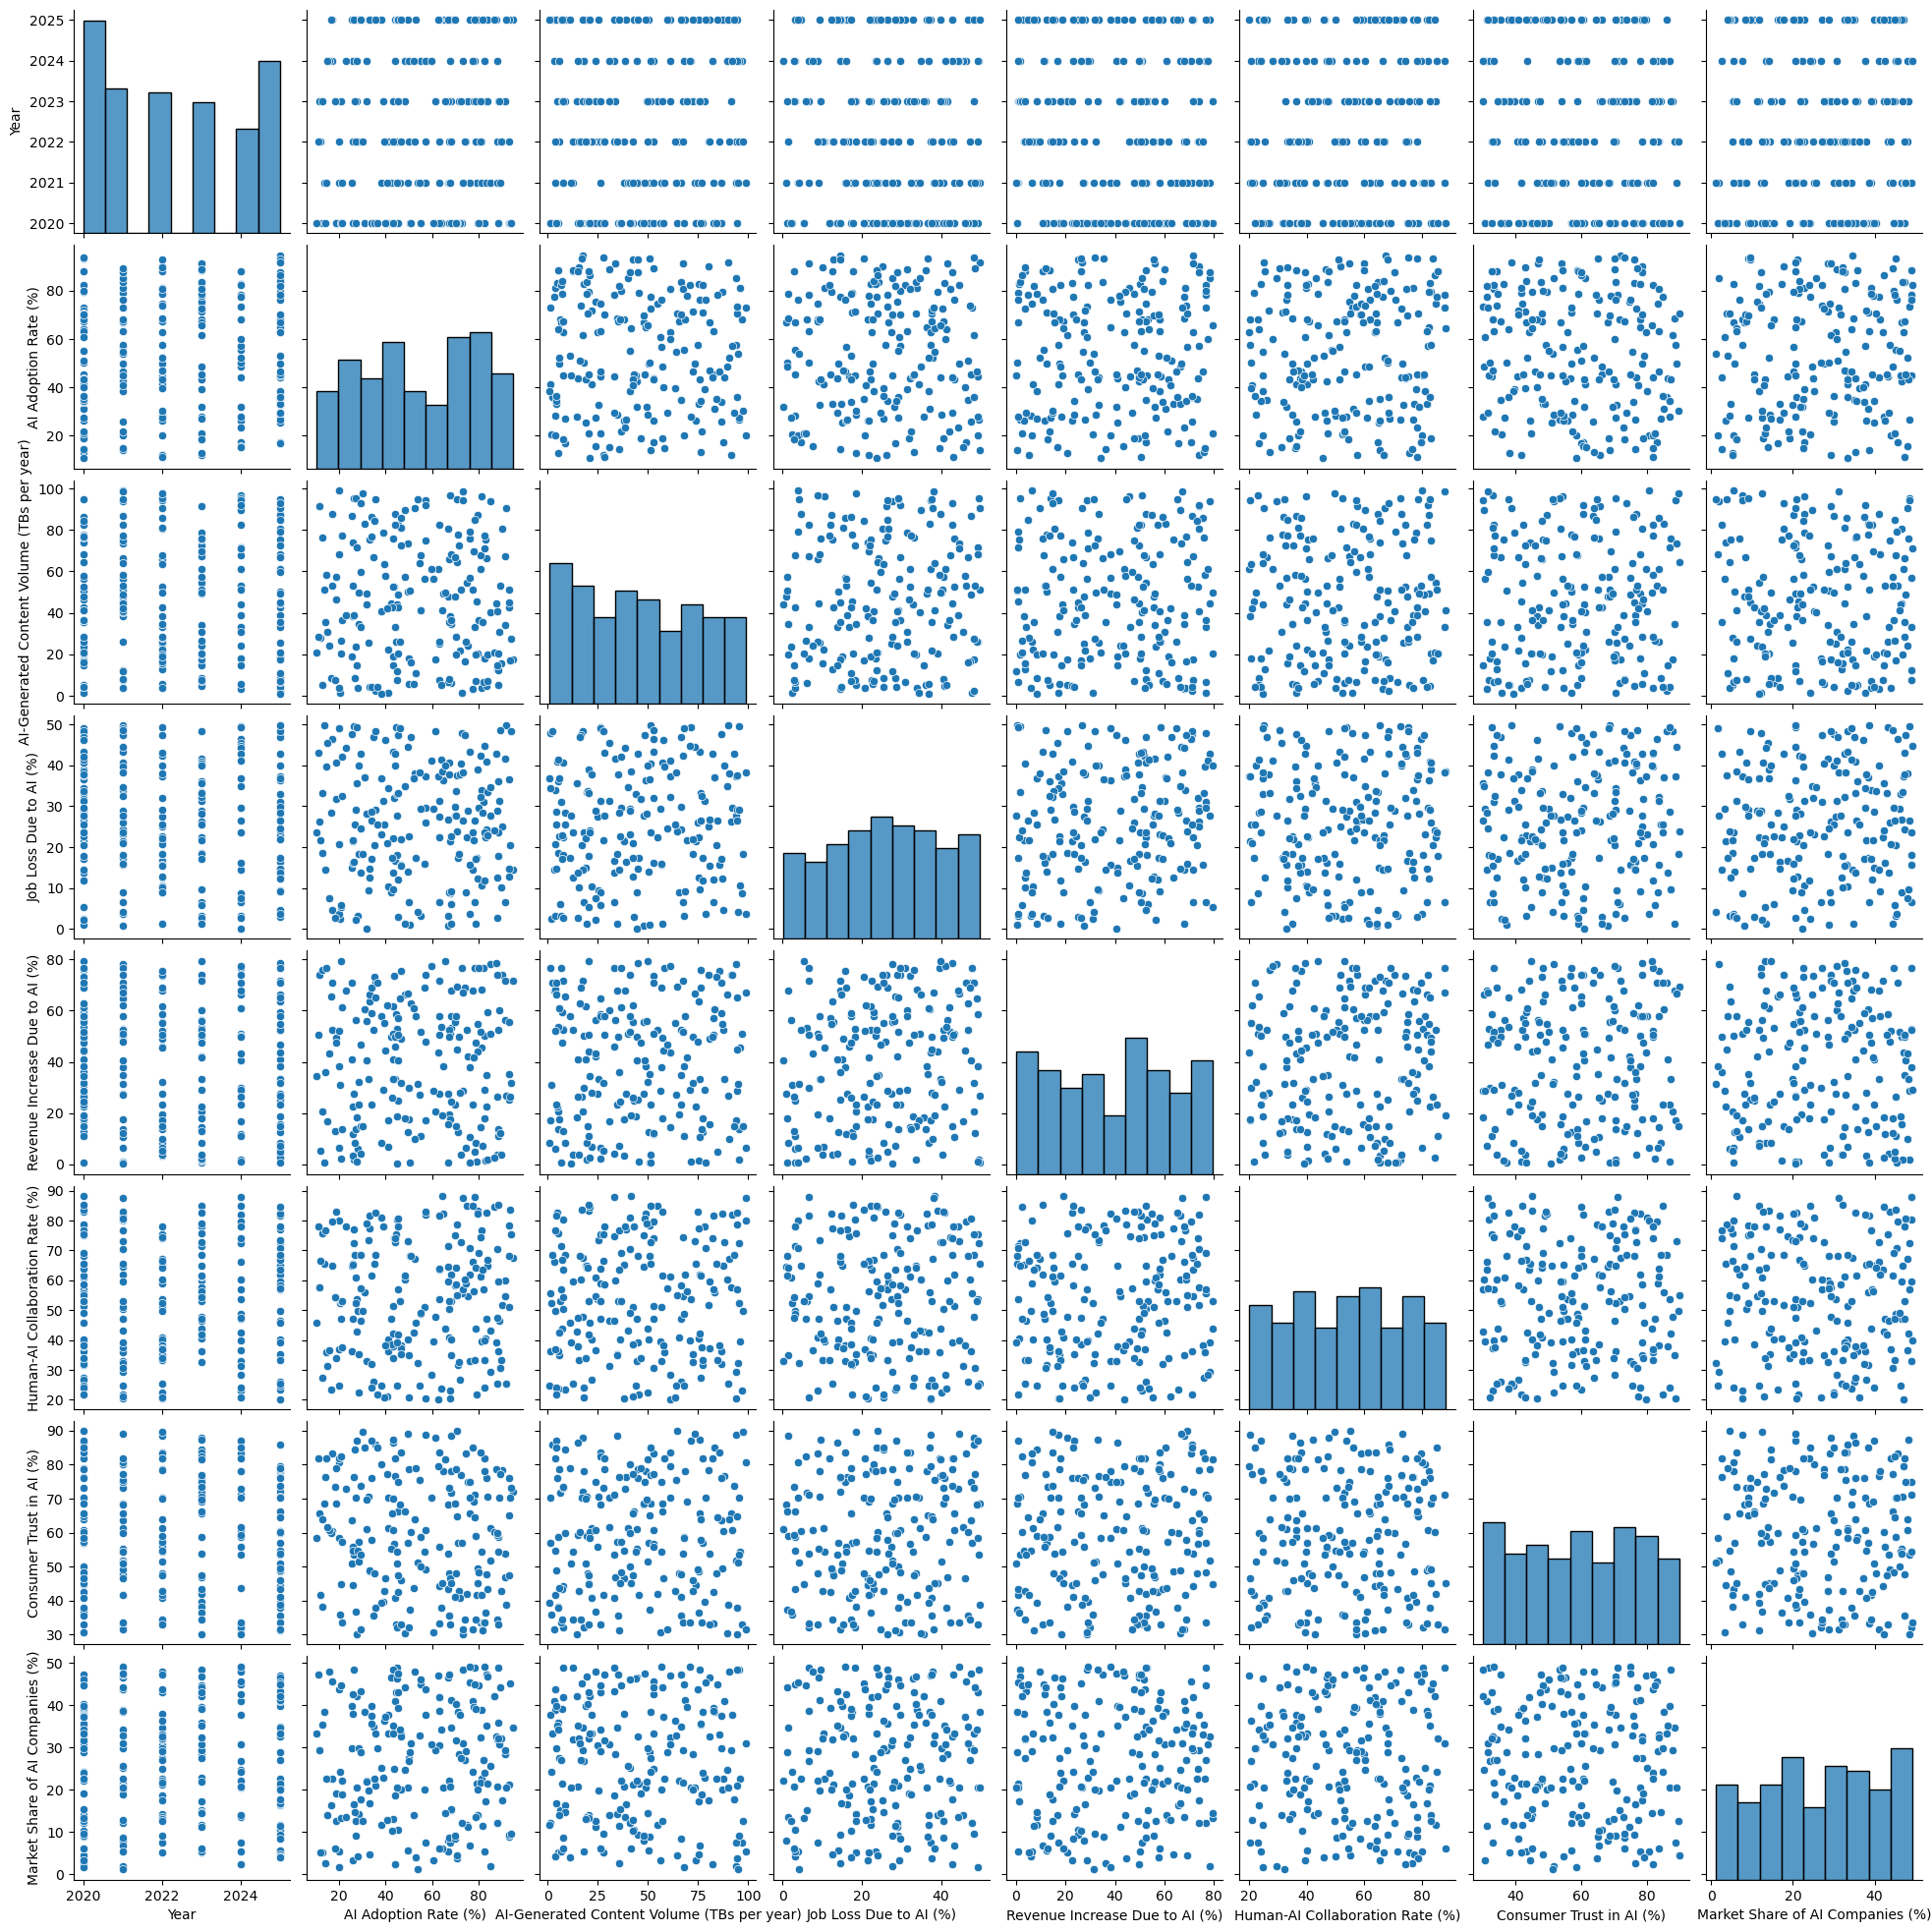

In [59]:
sns.pairplot(data=df)

plt.show()

A distribuição dos pontos nos gráficos de dispersão aparentam indicar pouca ou nenhuma correlação entre as variáveis.

Elaborando uma matriz de correlação, essa ausência de relações é reforçada.

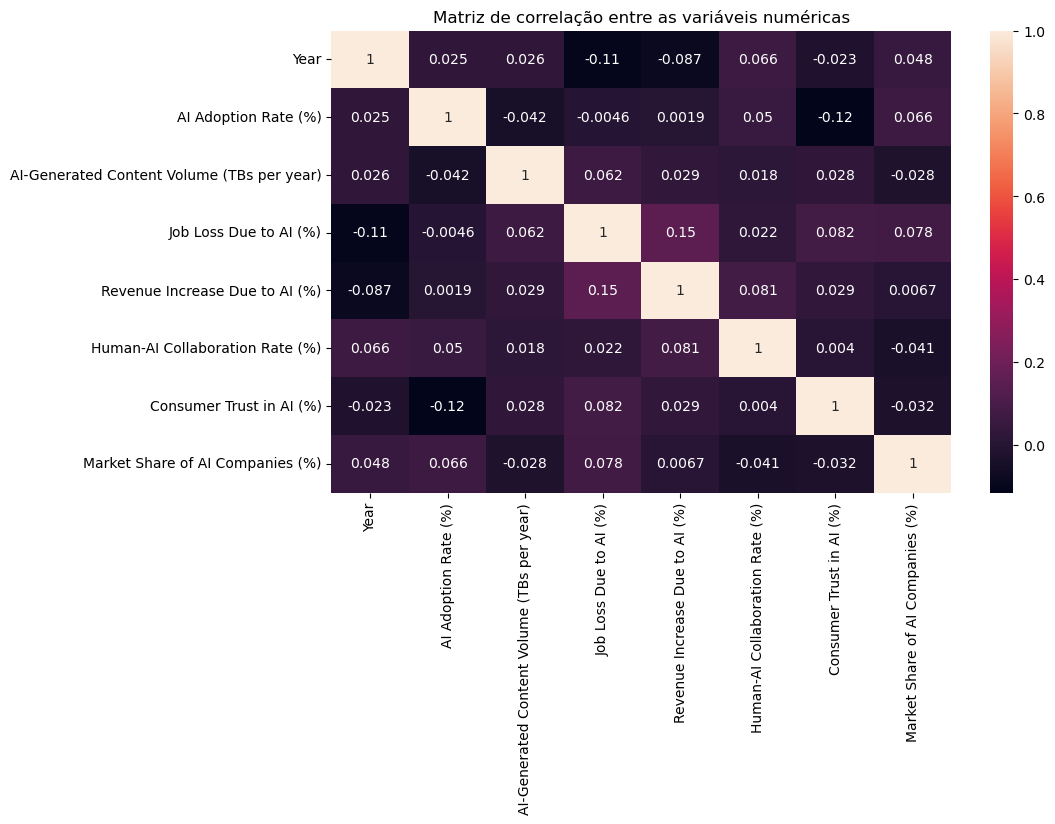

In [60]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, ax=ax)

plt.title("Matriz de correlação entre as variáveis numéricas")
plt.show()

As maiores correlações são entre receita e perda de emprego; entre adoção de IA e confiança do consumidor em IA. Entretanto, por serem pequenas, pode ser que se trate de correlações espúrias.

Há uma outra consideração a ser feita, tecnologias de IA podem impactar de forma diferente os diversos setores ou países onde é inserida.

A função abaixo realiza um plot da matriz de correlação por valor de uma categoria

In [61]:
def plot_corr_category(df, category, num_cols=1):
    
    # parametriza o numero de linhas dado o número de colunas
    num_rows=int(np.ceil(df[category].nunique()//num_cols))

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 6 * num_rows))
    axes = axes.flatten()
    
    cat_values = df[category].unique()
    
    # Plota a matriz de correlação para cada valor da categoria
    for i in range(len(cat_values)):    
        mask = df[category]==cat_values[i]
        correlation_matrix = df[mask].select_dtypes(include='number').corr()

        sns.heatmap(correlation_matrix,
                    annot=True, 
                    ax=axes[i])

        axes[i].set_title(f'Matriz de correlação de {cat_values[i]}')
        axes[i].set_xticklabels(axes[i].get_xticklabels(),rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

O objetivo desses plots não é extrair diretamente alguma relação, mas mostrar que existem correlações entre os dados e que é importante levar em consideração as categorias as quais os dados pertencem.

Aplicando a função por país:

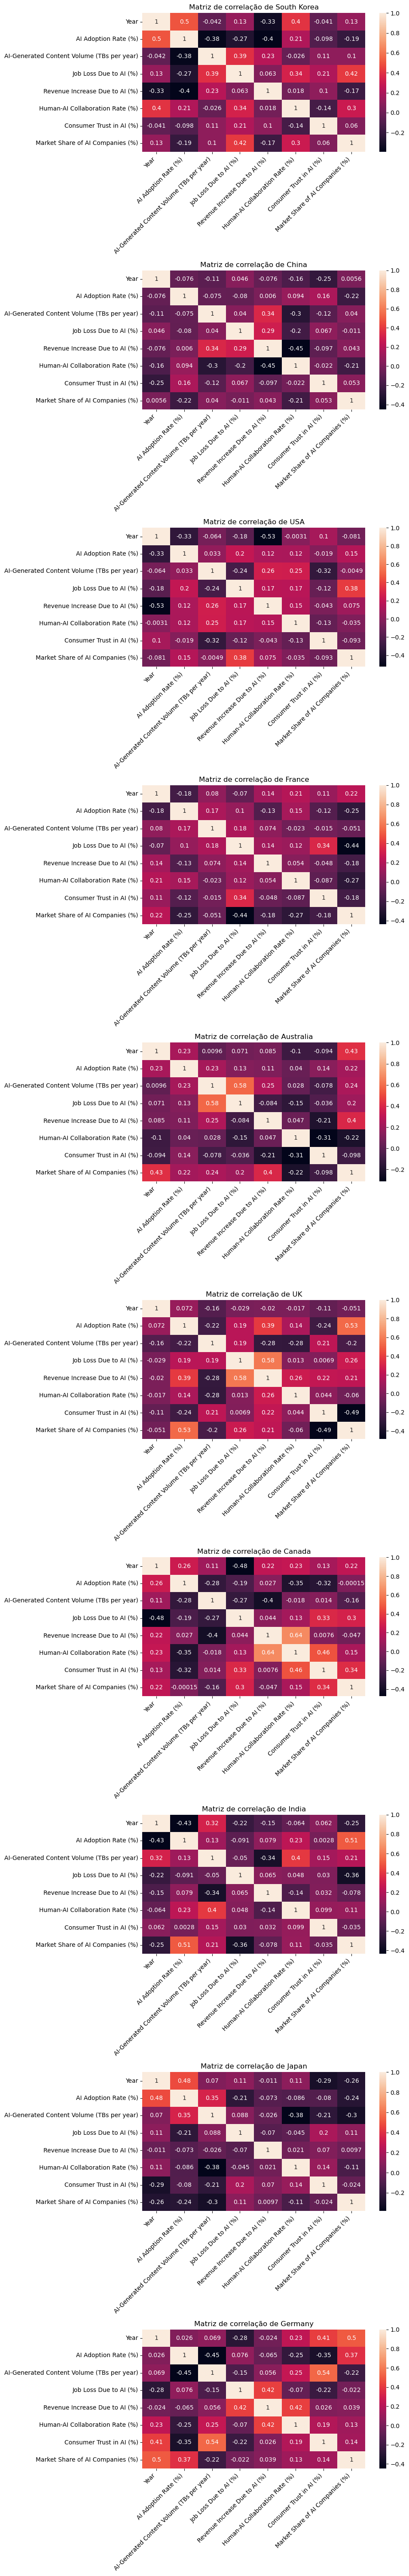

In [62]:
plot_corr_category(df,"Country")

Aplicando a função por setor de atuação:

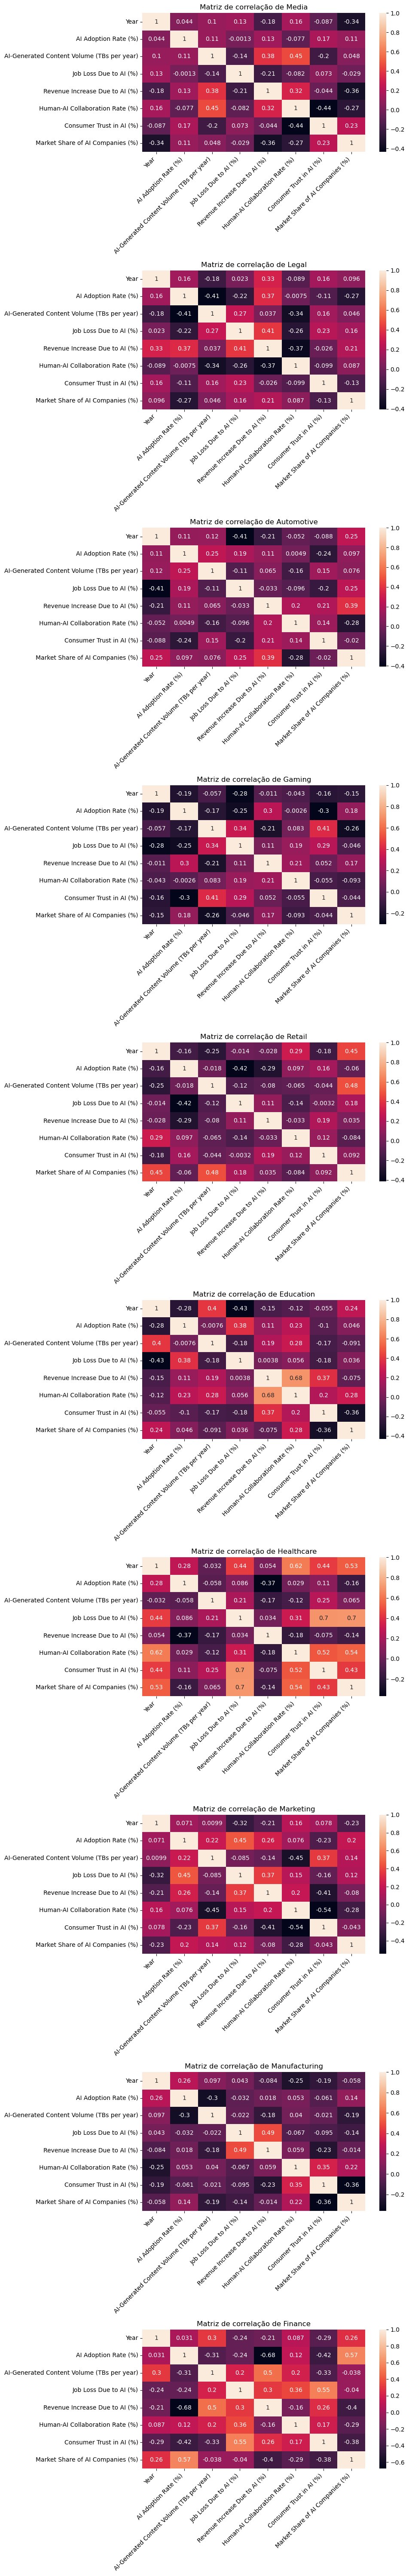

In [63]:
plot_corr_category(df,"Industry")

Por exemplo, a relação entre a taxa de adoção de IA e o aumento de receita é positivamente correlacionado (indicando retornos crescentes) nos setores de Marketing e Gaming, mas negativamente correlacionado (indicando retornos decrescentes) nos setores de Saúde e Finanças.

A relação média é mostrada no gráfico abaixo:

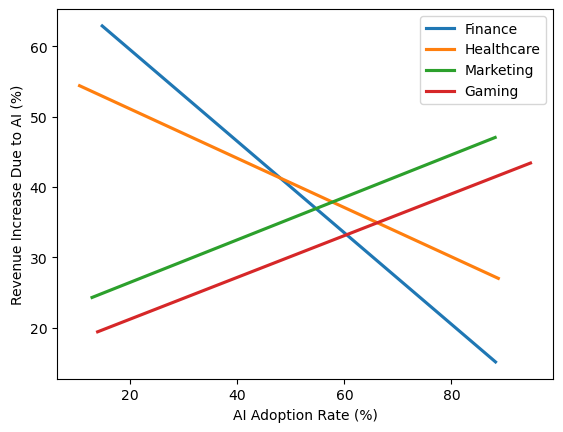

In [64]:
for industry in ["Finance", "Healthcare", "Marketing", "Gaming"]:
    sns.regplot(x="AI Adoption Rate (%)",
                y="Revenue Increase Due to AI (%)",
                data=df[df["Industry"]==industry],
                ci=None,
                label=industry,
                scatter=False)

plt.legend()
plt.show()

Em termos de regulação, parece que regulações moderadas e duras levam a relações diferente entre as variáveis em comparação com uma regulação mais leniente:

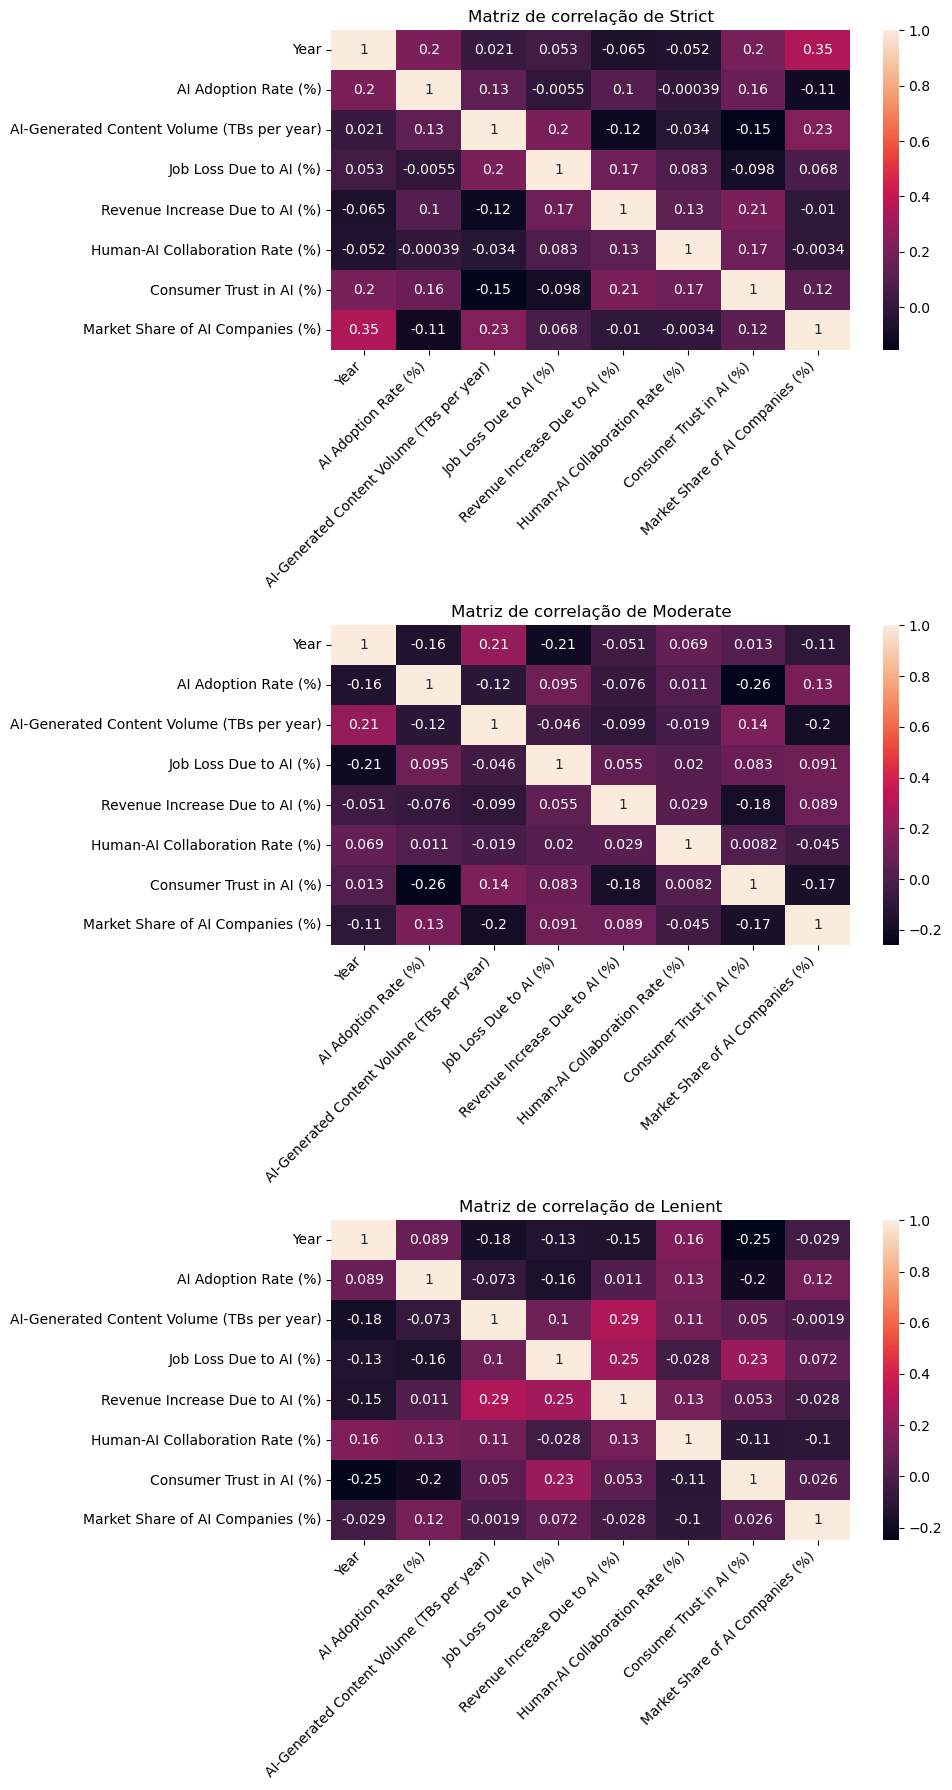

In [65]:
plot_corr_category(df,"Regulation Status")